<a href="https://colab.research.google.com/github/hgkim-gnbeng/tunnel_fire_dynamics_book/blob/book_example/%EC%98%88%EC%A0%9C_4_12_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
def HRR_curve(t, peak_HRR=None, specific_params=None):

    #5~100MW 범위의 HRR 곡선 생성 함수
    #Parameters:
    #t: 시간 배열 [초]
    #peak_HRR: 최대 열방출률 [MW] (5, 10, 15, 20, 30, 100 중 선택)
    #specific_params: 사용자 정의 파라미터 딕셔너리 (선택사항)
    #    Returns:
    #Q: 열방출률 배열 [MW]
    # 표에 제공된 기본 파라미터 (화재강도별)

    params = {
        5: {"alpha": 0.025, "beta": 0.002, "t_grow": 450, "t_hold": 560},
        10: {"alpha": 0.05, "beta": 0.002, "t_grow": 450, "t_hold": 556},
        15: {"alpha": 0.075, "beta": 0.002, "t_grow": 450, "t_hold": 554},
        20: {"alpha": 0.1, "beta": 0.002, "t_grow": 450, "t_hold": 552},
        30: {"alpha": 0.15, "beta": 0.002, "t_grow": 450, "t_hold": 552},
        100: {"alpha": 0.5, "beta": 0.002, "t_grow": 450, "t_hold": 550.6}
    }

    # 사용자 정의 파라미터 또는 기본 파라미터 선택
    if specific_params:
        alpha = specific_params.get("alpha")
        beta = specific_params.get("beta", 0.002)
        t_grow = specific_params.get("t_grow", 450)
        t_hold = specific_params.get("t_hold")
        peak_MW = specific_params.get("peak_HRR", peak_HRR)
    else:
        # 유효한 화재강도 범위 내 확인
        if peak_HRR not in params:
            valid_HRRs = list(params.keys())
            print(f"유효한 화재강도: {valid_HRRs}에서 선택하세요")
            return np.zeros_like(t)

        alpha = params[peak_HRR]["alpha"]
        beta = params[peak_HRR]["beta"]
        t_grow = params[peak_HRR]["t_grow"]
        t_hold = params[peak_HRR]["t_hold"]
        peak_MW = peak_HRR

    # 성장+유지 종료 시점
    t_peak = t_grow + t_hold

    # 열방출률 계산
    Q = np.zeros_like(t, dtype=float)

    # 성장 단계: Q = αt² (화재성장식)
    mask1 = t < t_grow
    Q[mask1] = alpha * t[mask1]**2 / 1000  # kW → MW 변환

    # 정점유지 단계: Q = Qmax
    mask2 = (t >= t_grow) & (t < t_peak)
    Q[mask2] = peak_MW

    # 감쇠 단계: Q = Qmax·EXP(-β·t)
    mask3 = t >= t_peak
    Q[mask3] = peak_MW * np.exp(-beta * (t[mask3] - t_peak))

    return Q

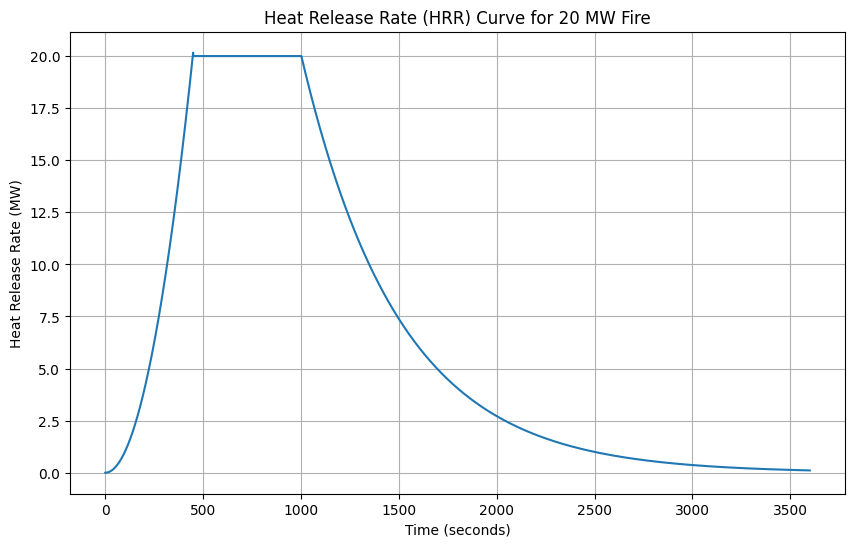

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 시간 배열 생성 (0초부터 3600초까지 1초 간격)
t = np.arange(0, 3601, 1)

# 화재 강도 입력 (원하는 값으로 변경하세요: 5, 10, 15, 20, 30, 100)
input_hrr = 20

# HRR_curve 함수를 사용하여 열방출률 계산
Q = HRR_curve(t, peak_HRR=input_hrr)

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(t, Q)
plt.title(f'Heat Release Rate (HRR) Curve for {input_hrr} MW Fire')
plt.xlabel('Time (seconds)')
plt.ylabel('Heat Release Rate (MW)')
plt.grid(True)
plt.show()